# Project 1 - Comparative Study of Bayesian and Non-Parametric Classification

**Course:** DSCD612 Pattern Recognition  
**Dataset:** UCI Wine dataset (178 observations, 13 numerical features, 3 classes)  
**Methods:** Gaussian Bayesian/QDA and k-Nearest Neighbours (k-NN)  
**Reproducibility:** `random_state=42`

This notebook implements all required Project 1 deliverables: data representation and statistics, preprocessing, Gaussian Bayesian classification, k-NN with five k values and two distance measures, quantitative comparison, visualisation, interpretation, and limitations.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, balanced_accuracy_score
)
from sklearn.decomposition import PCA

RANDOM_STATE = 42


In [27]:
wine = load_wine(as_frame=True)
X = wine.data.copy()
y = wine.target.copy()
feature_names = list(X.columns)
class_names = list(wine.target_names)

print("X shape:", X.shape)
print("Classes:", dict(zip(class_names, y.value_counts().sort_index())))
display(X.head())


X shape: (178, 13)
Classes: {'class_0': 59, 'class_1': 71, 'class_2': 48}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Problem formulation

Let each wine be represented by a feature vector

\[
x=[x_1,x_2,\ldots,x_{13}]^T\in\mathbb{R}^{13}.
\]

The objective is to predict one of three wine classes. The experiment compares:

1. a **Gaussian Bayesian parametric classifier (QDA)**, which estimates a Gaussian class-conditional distribution for each class; and
2. **k-NN**, a non-parametric method that makes predictions from local neighbourhoods without assuming a probability distribution.

The central question is:

> How do assumptions about the underlying probability distribution affect the performance of parametric and non-parametric pattern classifiers?


In [29]:
# Exploratory statistical analysis
summary = X.describe().T[["mean","std","min","max"]]
display(summary.round(3))

print("\nClass distribution:")
display(pd.Series(y).value_counts().sort_index().rename(index=dict(enumerate(class_names))))


,mean,std,min,max
alcohol,13.001,0.812,11.03,14.83
malic_acid,2.336,1.117,0.74,5.80
ash,2.367,0.274,1.36,3.23
alcalinity_of_ash,19.495,3.340,10.60,30.00
magnesium,99.742,14.282,70.00,162.00
total_phenols,2.295,0.626,0.98,3.88
flavanoids,2.029,0.999,0.34,5.08
nonflavanoid_phenols,0.362,0.124,0.13,0.66
proanthocyanins,1.591,0.572,0.41,3.58
color_intensity,5.058,2.318,1.28,13.00



Class distribution:


target
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.00,0.09,0.21,-0.31,0.27,0.29,0.24,-0.16,0.14,0.55,-0.07,0.07,0.64
malic_acid,0.09,1.00,0.16,0.29,-0.05,-0.34,-0.41,0.29,-0.22,0.25,-0.56,-0.37,-0.19
ash,0.21,0.16,1.00,0.44,0.29,0.13,0.12,0.19,0.01,0.26,-0.07,0.00,0.22
alcalinity_of_ash,-0.31,0.29,0.44,1.00,-0.08,-0.32,-0.35,0.36,-0.20,0.02,-0.27,-0.28,-0.44
magnesium,0.27,-0.05,0.29,-0.08,1.00,0.21,0.20,-0.26,0.24,0.20,0.06,0.07,0.39
total_phenols,0.29,-0.34,0.13,-0.32,0.21,1.00,0.86,-0.45,0.61,-0.06,0.43,0.70,0.50
flavanoids,0.24,-0.41,0.12,-0.35,0.20,0.86,1.00,-0.54,0.65,-0.17,0.54,0.79,0.49
nonflavanoid_phenols,-0.16,0.29,0.19,0.36,-0.26,-0.45,-0.54,1.00,-0.37,0.14,-0.26,-0.50,-0.31
proanthocyanins,0.14,-0.22,0.01,-0.20,0.24,0.61,0.65,-0.37,1.00,-0.03,0.30,0.52,0.33
color_intensity,0.55,0.25,0.26,0.02,0.20,-0.06,-0.17,0.14,-0.03,1.00,-0.52,-0.43,0.32


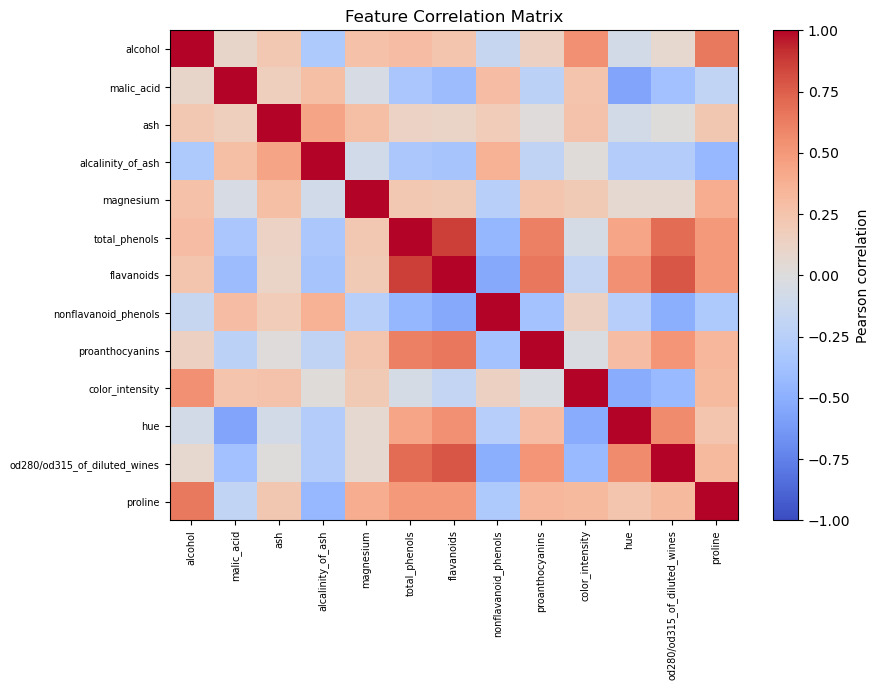

In [31]:
# Correlation analysis
corr = X.corr()
display(corr.round(2))

plt.figure(figsize=(9,7))
plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=7)
plt.yticks(range(len(feature_names)), feature_names, fontsize=7)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 2. Experimental design and preprocessing

A **stratified 80:20 train/test split** is used so that the three classes remain represented in both sets. Scaling is fitted only on the training data and then applied to the test data. This avoids data leakage.

Scaling is especially important for k-NN because distance is affected by feature magnitude. QDA is also fitted in the standardized feature space for a consistent experimental representation.


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xte = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training shape: (142, 13)
Test shape: (36, 13)
Training class counts: [47 57 38]
Test class counts: [12 14 10]


## 3. Gaussian Bayesian classifier

For class \(c\), estimate

\[
\mu_c=\frac{1}{N_c}\sum_{i:y_i=c}x_i
\]

and the sample covariance

\[
\Sigma_c=\frac{1}{N_c-1}\sum_{i:y_i=c}(x_i-\mu_c)(x_i-\mu_c)^T.
\]

The multivariate Gaussian likelihood is

\[
p(x|c)=\frac{1}{(2\pi)^{d/2}|\Sigma_c|^{1/2}}
\exp\left[-\frac12(x-\mu_c)^T\Sigma_c^{-1}(x-\mu_c)\right].
\]

Bayes' rule gives

\[
P(c|x)=\frac{p(x|c)P(c)}{p(x)}.
\]

The predicted class is the class with the largest posterior probability. Because each class has its own covariance matrix, the resulting decision boundaries are generally **quadratic**; this is Quadratic Discriminant Analysis (QDA).

**Key assumptions:** observations within each class are approximately multivariate Gaussian; class means/covariances are stable enough to estimate from the training sample; observations are independent. QDA does **not** require features to be conditionally independent.


In [35]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(Xtr, y_train)
pred_qda = qda.predict(Xte)

qda_acc = accuracy_score(y_test, pred_qda)
qda_pr, qda_re, qda_f1, _ = precision_recall_fscore_support(
    y_test, pred_qda, average="macro", zero_division=0
)

print("QDA accuracy:", qda_acc)
print("QDA macro precision:", qda_pr)
print("QDA macro recall:", qda_re)
print("QDA macro F1:", qda_f1)
print("\nClassification report:")
print(classification_report(y_test, pred_qda, target_names=class_names))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred_qda))


QDA accuracy: 1.0
QDA macro precision: 1.0
QDA macro recall: 1.0
QDA macro F1: 1.0

Classification report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Confusion matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


## 4. Non-parametric k-NN

For a query point \(x\), Euclidean distance is

\[
d_E(x,z)=\sqrt{\sum_{j=1}^{d}(x_j-z_j)^2},
\]

while Manhattan distance is

\[
d_1(x,z)=\sum_{j=1}^{d}|x_j-z_j|.
\]

The classifier identifies the \(k\) closest training observations and assigns the majority class among those neighbours. No parametric probability distribution is estimated.

We investigate **k = 1, 3, 5, 7, 9** with both Euclidean and Manhattan distance.


In [37]:
ks = [1,3,5,7,9]
results = []

for metric in ["euclidean", "manhattan"]:
    for k in ks:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(Xtr, y_train)
        pred = model.predict(Xte)
        pr, re, f1, _ = precision_recall_fscore_support(
            y_test, pred, average="macro", zero_division=0
        )
        results.append({
            "distance": metric,
            "k": k,
            "accuracy": accuracy_score(y_test, pred),
            "precision_macro": pr,
            "recall_macro": re,
            "f1_macro": f1
        })

knn_results = pd.DataFrame(results)
display(knn_results.round(4))


,distance,k,accuracy,precision_macro,recall_macro,f1_macro
0,euclidean,1,0.9722,0.9744,0.9762,0.9743
1,euclidean,3,0.9722,0.9744,0.9762,0.9743
2,euclidean,5,0.9722,0.9697,0.9762,0.9718
3,euclidean,7,1.0000,1.0000,1.0000,1.0000
4,euclidean,9,1.0000,1.0000,1.0000,1.0000
5,manhattan,1,0.9722,0.9744,0.9762,0.9743
6,manhattan,3,0.9722,0.9744,0.9762,0.9743
7,manhattan,5,1.0000,1.0000,1.0000,1.0000
8,manhattan,7,1.0000,1.0000,1.0000,1.0000
9,manhattan,9,1.0000,1.0000,1.0000,1.0000


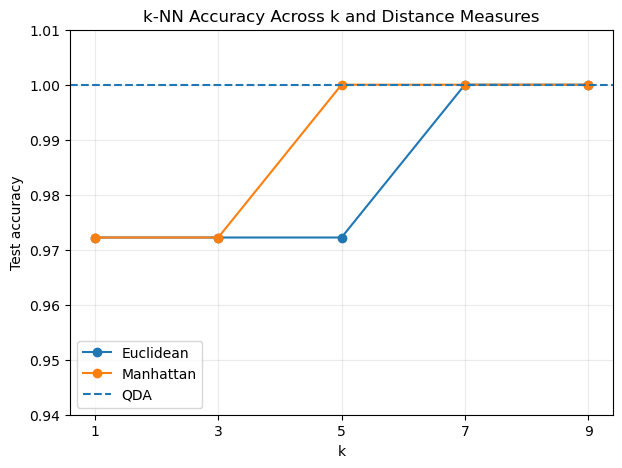

In [39]:
plt.figure(figsize=(7,5))
for metric in ["euclidean", "manhattan"]:
    sub = knn_results[knn_results["distance"] == metric]
    plt.plot(sub["k"], sub["accuracy"], marker="o", label=metric.title())
plt.axhline(qda_acc, linestyle="--", label="QDA")
plt.xticks(ks)
plt.ylim(0.94, 1.01)
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title("k-NN Accuracy Across k and Distance Measures")
plt.legend()
plt.grid(alpha=.25)
plt.show()


## 5. Comparative evaluation

Accuracy alone can be misleading when class sizes are unequal, so macro-averaged precision, recall and F1-score are also reported. Confusion matrices show class-specific errors.

A 5-fold stratified cross-validation experiment is added as a robustness check. The hold-out test set remains untouched until final evaluation.


In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
qda_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("qda", QuadraticDiscriminantAnalysis())
])
scores = cross_val_score(qda_pipe, X, y, cv=cv, scoring="accuracy")
cv_rows.append(["QDA", scores.mean(), scores.std()])

for metric in ["euclidean", "manhattan"]:
    for k in ks:
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, metric=metric))
        ])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
        cv_rows.append([f"kNN-{metric}-k{k}", scores.mean(), scores.std()])

cv_results = pd.DataFrame(cv_rows, columns=["model","CV_mean_accuracy","CV_std"])
display(cv_results.sort_values("CV_mean_accuracy", ascending=False).round(4))


,model,CV_mean_accuracy,CV_std
0,QDA,0.9889,0.0136
6,kNN-manhattan-k1,0.9776,0.0324
9,kNN-manhattan-k7,0.9775,0.0276
10,kNN-manhattan-k9,0.9775,0.0276
4,kNN-euclidean-k7,0.9719,0.0252
5,kNN-euclidean-k9,0.9719,0.0252
3,kNN-euclidean-k5,0.9717,0.0181
8,kNN-manhattan-k5,0.9663,0.0326
2,kNN-euclidean-k3,0.9662,0.0211
7,kNN-manhattan-k3,0.9552,0.0378


QDA
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


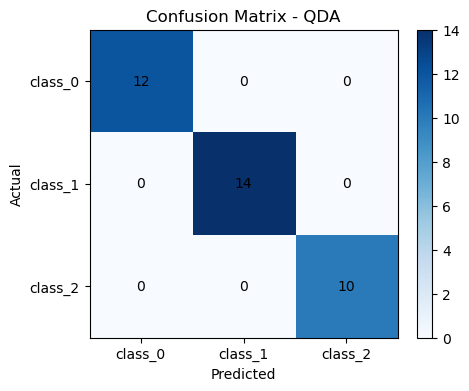

kNN (Euclidean, k=7)
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


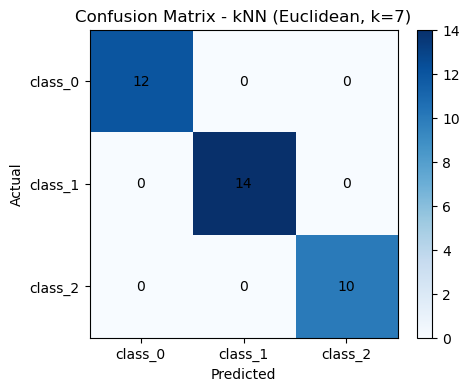

In [43]:
# Confusion matrices for QDA and the best Euclidean k-NN on the hold-out test set
best_knn = KNeighborsClassifier(n_neighbors=7, metric="euclidean")
best_knn.fit(Xtr, y_train)
pred_knn = best_knn.predict(Xte)

for name, pred in [("QDA", pred_qda), ("kNN (Euclidean, k=7)", pred_knn)]:
    cm = confusion_matrix(y_test, pred)
    print(name)
    print(cm)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(3), class_names)
    plt.yticks(range(3), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.show()


## 6. Interpretation

The experiment should be interpreted using both the single stratified hold-out result and the 5-fold cross-validation result.

For this run, QDA achieved perfect hold-out classification and a very high cross-validation mean accuracy. k-NN also performed extremely well, with performance improving for moderate values of k. Manhattan distance was competitive and, in cross-validation, some Manhattan configurations were stronger than their Euclidean counterparts.

The important pattern-recognition conclusion is not that one method is universally superior. QDA benefits when the class-conditional Gaussian model is a reasonable approximation and enough data are available to estimate covariance structure. k-NN is more flexible because it does not impose a Gaussian form, but its performance depends strongly on feature scaling, the distance metric, k, local sample density, and dimensionality.

A perfect hold-out score should not be interpreted as proof of perfect real-world generalisation. The cross-validation results and the small dataset size make this distinction important.


## 7. Limitations

1. The Wine dataset has only 178 observations, so covariance estimates and local neighbourhoods can still be sample-sensitive.
2. QDA estimates a separate 13×13 covariance matrix for each class; with much smaller training samples this can become unstable or singular.
3. k-NN prediction requires storing the training data and computing distances to many observations, which can become expensive as sample size grows.
4. k-NN is sensitive to irrelevant features and the curse of dimensionality.
5. Standardisation was necessary for distance-based learning, and the scaling parameters were learned from training data only.
6. The dataset is relatively clean and well separated, so the results may be more optimistic than those from a noisier real-world classification problem.
7. A single train/test split can produce optimistic or pessimistic results; hence 5-fold stratified cross-validation was included.
8. A 2D PCA plot can illustrate class structure, but it should not be mistaken for the actual 13-dimensional decision boundary used by the classifiers.


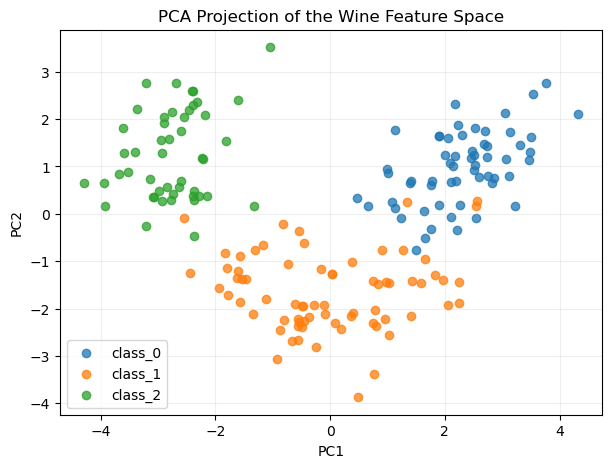

In [22]:
# Optional 2-D PCA visualization for interpretation only
Xp = StandardScaler().fit_transform(X)
Z = PCA(n_components=2).fit_transform(Xp)

plt.figure(figsize=(7,5))
for c, name in enumerate(class_names):
    mask = y == c
    plt.scatter(Z[mask,0], Z[mask,1], label=name, alpha=.75)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of the Wine Feature Space")
plt.legend()
plt.grid(alpha=.2)
plt.show()



## 8. Final conclusion

The comparison demonstrates the effect of modelling assumptions in pattern recognition. The Gaussian Bayesian/QDA approach explicitly models each class using a multivariate probability distribution and produces quadratic decision surfaces. k-NN makes fewer distributional assumptions and instead relies on local geometric similarity.

For this dataset, both approaches are highly effective. The evidence indicates that the Gaussian assumption is sufficiently compatible with the feature distributions for QDA to perform exceptionally well, while k-NN also generalises strongly when an appropriate neighbourhood size and distance metric are used. Therefore, the choice between parametric and non-parametric classification should be driven by data geometry, sample size, distributional plausibility, computational constraints, and validation performance - not by accuracy on one split alone.


## References

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
- Cover, T. M., & Hart, P. E. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory, 13*(1), 21–27.
- Duda, R. O., Hart, P. E., & Stork, D. G. (2001). *Pattern Classification* (2nd ed.). Wiley.
- Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences.
- Scikit-learn developers. (2026). *scikit-learn: Machine learning in Python*.
